In [2]:
import pandas as pd
url="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df=pd.read_csv(url)
print(df.head())
print(df.shape)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
(8

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [4]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [7]:
df.groupby("Embarked")["Survived"].mean()

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.336957


In [8]:
df.groupby("Pclass")["Survived"].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


In [9]:
df.groupby("Sex")["Survived"].mean()

,Survived
Sex,
female,0.742038
male,0.188908


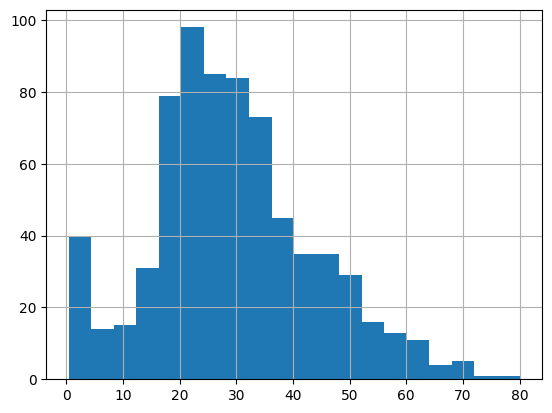

In [11]:
df["Age"].describe()
import matplotlib.pyplot as plt

df["Age"].hist(bins=20)

plt.show()

In [12]:
df["Child"] = df["Age"] < 18

df.groupby("Child")["Survived"].mean()

,Survived
Child,
False,0.361183
True,0.539823


In [16]:
df["Age"]=df["Age"].fillna(df["Age"].median())
df = df.drop("Name", axis=1)

In [19]:
df=pd.get_dummies(df,drop_first=True)
print(df.head())
print(df.shape)

   PassengerId  Survived  Pclass   Age  SibSp  Parch     Fare  Child  \
0            1         0       3  22.0      1      0   7.2500  False   
1            2         1       1  38.0      1      0  71.2833  False   
2            3         1       3  26.0      0      0   7.9250  False   
3            4         1       1  35.0      1      0  53.1000  False   
4            5         0       3  35.0      0      0   8.0500  False   

   Sex_male  Ticket_110413  ...  Cabin_F G63  Cabin_F G73  Cabin_F2  \
0      True          False  ...        False        False     False   
1     False          False  ...        False        False     False   
2     False          False  ...        False        False     False   
3     False          False  ...        False        False     False   
4      True          False  ...        False        False     False   

   Cabin_F33  Cabin_F38  Cabin_F4  Cabin_G6  Cabin_T  Embarked_Q  Embarked_S  
0      False      False     False     False    False       Fa

In [20]:
y=df["Survived"]
x=df.drop("Survived",axis=1)

In [24]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(x_train,y_train)
print("model trained")

model trained


In [27]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
cm = confusion_matrix(y_test, y_pred)

print(cm)
print(classification_report(y_test, y_pred))

Accuracy: 0.8268156424581006
[[97  8]
 [23 51]]
              precision    recall  f1-score   support

           0       0.81      0.92      0.86       105
           1       0.86      0.69      0.77        74

    accuracy                           0.83       179
   macro avg       0.84      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179



In [30]:
import joblib

joblib.dump(model, "titanic_model.pkl")

print("Model Saved")

Model Saved


In [32]:
import joblib

model = joblib.load("titanic_model.pkl")

print("Model Loaded")

Model Loaded


In [33]:
prediction = model.predict(x_test[:5])

print(prediction)

[0 0 0 1 0]
